# DJ User story - Genre Bridges

Als DJ will ich Brücken zwischen Subgenres, eine kurze Liste mit fünf Tracks, die zwei Stile im Set nahtlos verbinden.

In [68]:
import math
import time
import random
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Any, Tuple, Optional

In [49]:
# Rapid API
RAPIDAPI_KEY = "[RAPIDAPI_KEY]"
RAPIDAPI_HOST = "track" + chr(45) + "analysis.p.rapidapi.com"
RAPID_REGION = "EU"

# Spotify Web API
SPOTIFY_CLIENT_ID = "[SPOTIFY_CLIENT_ID]"
SPOTIFY_CLIENT_SECRET = "[SPOTIFY_CLIENT_SECRET]"
SPOTIFY_REDIRECT_URI = "http://localhost:8721/callback"

# Settings
SOURCE_SUBGENRE = "pop"
TARGET_SUBGENRE = "classic"

CANDIDATES_PER_SIDE = 60
MARKET = "US"

assert(RAPIDAPI_KEY != "[RAPIDAPI_KEY]")
assert(SPOTIFY_CLIENT_ID != "[SPOTIFY_CLIENT_ID]")
assert(SPOTIFY_CLIENT_SECRET != "[SPOTIFY_CLIENT_SECRET]")


## Spotify Auth und Hilfsfunktionen

In [50]:
def get_spotify_token(client_id: str, client_secret: str) -> str:
    url = "https://accounts.spotify.com/api/token"
    data = {"grant_type": "client_credentials"}
    resp = requests.post(url, data=data, auth=(client_id, client_secret), timeout=30)
    resp.raise_for_status()
    return resp.json()["access_token"]


def sp_get(url: str, token: str, params: Dict[str, Any] = None) -> Dict[str, Any]:
    headers = {"Authorization": f"Bearer {token}"}
    resp = requests.get(url, headers=headers, params=params, timeout=30)
    resp.raise_for_status()
    return resp.json()


def get_available_genre_seeds(token: str) -> List[str]:
    url = "https://api.spotify.com/v1/recommendations/available-genre-seeds"
    try:
        return sp_get(url, token)["genres"]
    except Exception:
        return []


## Get Tracks from Spotify

In [51]:
def search_artists_by_genre(genre: str, token: str, limit: int = 30) -> List[Dict[str, Any]]:
    url = "https://api.spotify.com/v1/search"
    params = {
        "q": f'genre:"{genre}"',
        "type": "artist",
        "limit": min(50, limit),
    }
    data = sp_get(url, token, params=params)
    return data.get("artists", {}).get("items", [])


def get_artist_top_tracks(artist_id: str, token: str, market: str = "US") -> List[Dict[str, Any]]:
    url = f"https://api.spotify.com/v1/artists/{artist_id}/top-tracks"
    params = {"market": market}
    data = sp_get(url, token, params=params)
    return data.get("tracks", [])


def get_recommendation_track_ids_by_seed(genre: str, token: str, n: int) -> List[Dict[str, Any]]:
    url = "https://api.spotify.com/v1/recommendations"
    params = {"seed_genres": genre, "limit": min(100, n)}
    if random.random() < 0.6:
        params["target_tempo"] = random.randint(110, 140)
    if random.random() < 0.6:
        params["target_popularity"] = random.randint(30, 80)
    data = sp_get(url, token, params=params)
    tracks = data.get("tracks", [])
    out = []
    for t in tracks:
        artists = ", ".join(a["name"] for a in t["artists"])
        out.append({
            "track_id": t["id"],
            "track_name": t["name"],
            "artists": artists,
            "genre_seed": genre,
            "spotify_url": t["external_urls"]["spotify"],
        })
    return out


def get_track_ids_for_subgenre(genre: str, token: str, n: int, market: str = "US") -> List[Dict[str, Any]]:
    out = []
    seen = set()

    seeds = set(get_available_genre_seeds(token))
    if genre in seeds:
        try:
            out = get_recommendation_track_ids_by_seed(genre, token, n)
        except Exception:
            out = []

    if len(out) < n:
        try:
            artists = search_artists_by_genre(genre, token, limit=50)
            for a in artists:
                top = get_artist_top_tracks(a["id"], token, market=market)
                for t in top:
                    tid = t["id"]
                    if tid in seen:
                        continue
                    seen.add(tid)
                    artists_str = ", ".join(p["name"] for p in t["artists"])
                    out.append({
                        "track_id": tid,
                        "track_name": t["name"],
                        "artists": artists_str,
                        "genre_seed": genre,
                        "spotify_url": t["external_urls"]["spotify"],
                    })
                    if len(out) >= n:
                        break
                if len(out) >= n:
                    break
        except Exception:
            pass

    if len(out) < n:
        try:
            url = "https://api.spotify.com/v1/search"
            params = {"q": genre, "type": "track", "limit": 50}
            data = sp_get(url, token, params=params)
            for t in data.get("tracks", {}).get("items", []):
                tid = t["id"]
                if tid in seen:
                    continue
                seen.add(tid)
                artists_str = ", ".join(p["name"] for p in t["artists"])
                out.append({
                    "track_id": tid,
                    "track_name": t["name"],
                    "artists": artists_str,
                    "genre_seed": genre,
                    "spotify_url": t["external_urls"]["spotify"],
                })
                if len(out) >= n:
                    break
        except Exception:
            pass

    return out[:n]


## Get Track Features from Rapid API

In [52]:
def _parse_rapid_payload(data: dict) -> dict:
    out = {}
    out["camelot"] = data.get("camelot") or data.get("harmonic_key") or data.get("key_camelot")
    out["rapid_key"] = data.get("key") or data.get("musical_key")
    out["rapid_mode"] = data.get("mode")
    out["tempo"] = data.get("tempo") or data.get("bpm")
    e = data.get("energy")
    d = data.get("danceability")
    def _to01(v):
        if v is None:
            return None
        try:
            v = float(v)
        except Exception:
            return None
        if v > 1.5:
            return v / 100.0
        return v
    out["energy"] = _to01(e)
    out["danceability"] = _to01(d)
    out["popularity"] = data.get("popularity")
    return out


def get_camelot_for_track(track_id: str) -> dict:
    url = f"https://{RAPIDAPI_HOST}/pktx/spotify/{track_id}"
    headers = {
        "X" + chr(45) + "RapidAPI" + chr(45) + "Key": RAPIDAPI_KEY,
        "X" + chr(45) + "RapidAPI" + chr(45) + "Host": RAPIDAPI_HOST,
        "Accept": "application/json",
    }
    if RAPID_REGION:
        headers["X" + chr(45) + "RapidAPI" + chr(45) + "Region"] = RAPID_REGION
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    parsed = _parse_rapid_payload(data)
    if not parsed.get("camelot"):
        print("Hinweis, kein Camelot empfangen für", track_id, "Response:", data)
    return parsed


def batch_get_camelot(track_ids: list, sleep_s: float = 0.15, retries: int = 2) -> pd.DataFrame:
    rows = []
    for tid in track_ids:
        last_err = None
        for attempt in range(retries + 1):
            try:
                parsed = get_camelot_for_track(tid)
                rows.append({"track_id": tid, **parsed})
                break
            except Exception as e:
                last_err = str(e)
                time.sleep(sleep_s * (attempt + 1))
        else:
            rows.append({
                "track_id": tid, "camelot": None, "rapid_key": None, "rapid_mode": None,
                "tempo": None, "energy": None, "danceability": None, "popularity": None,
                "error": last_err,
            })
        time.sleep(sleep_s)
    df = pd.DataFrame(rows)
    df["tempo"] = pd.to_numeric(df["tempo"], errors="coerce")
    return df


## Brückenbau ;)

In [71]:
def camelot_neighbors(tag: str) -> set:
    if not tag or len(tag) < 2:
        return set()
    try:
        num = int(tag[:-1])
        let = tag[-1].upper()
    except Exception:
        return set()
    nums = [(num - 2) % 12 + 1, num, (num) % 12 + 1]
    lets = {let, "A" if let == "B" else "B"}
    return {f"{n}{l}" for n in nums for l in lets}


def key_compat_score(c1: str, c2: str) -> float:
    if not c1 or not c2:
        return 0.0
    if c1 == c2:
        return 1.0
    if c2 in camelot_neighbors(c1):
        return 0.7
    n2 = set()
    for n in camelot_neighbors(c1):
        n2 |= camelot_neighbors(n)
    if c2 in n2:
        return 0.4
    return 0.0


def tempo_compat_score(t1: float, t2: float) -> float:
    if not t1 or not t2 or np.isnan(t1) or np.isnan(t2):
        return 0.0
    cands = [t2, t2*2, t2/2]
    d = min(abs(float(t1) - float(c)) for c in cands)
    return max(0.0, 1.0 - d/20.0)


def energy_compat_score(e1: float, e2: float) -> float:
    if e1 is None or e2 is None or np.isnan(e1) or np.isnan(e2):
        return 0.0
    return max(0.0, 1.0 - abs(float(e1) - float(e2)))

def build_candidates(token: str, source_genre: str, target_genre: str, per_side: int = 60) -> pd.DataFrame:
    src = get_track_ids_for_subgenre(source_genre, token, per_side)
    tgt = get_track_ids_for_subgenre(target_genre, token, per_side)
    base = pd.DataFrame(src + tgt)

    camel = batch_get_camelot(base["track_id"].tolist())
    df = base.merge(camel, on="track_id", how="left")

    df["side"] = df["genre_seed"].apply(lambda g: "source" if g == source_genre else "target")
    return df


def compat_row(a: pd.Series, b: pd.Series) -> float:
    kc = key_compat_score(a.get("camelot"), b.get("camelot"))
    tc = tempo_compat_score(a.get("tempo"), b.get("tempo"))
    ec = energy_compat_score(a.get("energy"), b.get("energy"))
    return 0.5*kc + 0.3*tc + 0.2*ec

def _camelot_parse(s: str) -> Optional[tuple[int, str]]:
    if not isinstance(s, str):
        return None
    s = s.strip().upper()
    if not s:
        return None
    num = "".join(ch for ch in s if ch.isdigit())
    if not num:
        return None
    try:
        n = int(num)
    except Exception:
        return None
    if n < 1 or n > 12:
        return None
    let = "A" if "A" in s else ("B" if "B" in s else None)
    if let is None:
        return None
    return n, let

def _camelot_adjacent(a: str, b: str) -> bool:
    pa = _camelot_parse(a)
    pb = _camelot_parse(b)
    if pa is None or pb is None:
        return False
    na, la = pa
    nb, lb = pb
    if na == nb and la == lb:
        return True
    if na == nb and la != lb:
        return True
    if la == lb:
        diff = abs(na - nb) % 12
        diff = min(diff, 12 - diff)
        return diff == 1
    return False

def _avg_ed(row) -> float:
    e = pd.to_numeric(row.get("energy"), errors="coerce")
    d = pd.to_numeric(row.get("danceability"), errors="coerce")
    e = 0.5 if pd.isna(e) else float(e)
    d = 0.5 if pd.isna(d) else float(d)
    return 0.5 * e + 0.5 * d

def _tempo(row) -> float:
    t = pd.to_numeric(row.get("tempo"), errors="coerce")
    return 0.0 if pd.isna(t) else float(t)

def find_bridge(df: pd.DataFrame, k: int = 5) -> Tuple[pd.DataFrame, pd.DataFrame]:
    assert k >= 2, "k must be at least 2"

    src = df.loc[df["side"] == "source"].copy()
    tgt = df.loc[df["side"] == "target"].copy()

    src = src.assign(seed=src.apply(_avg_ed, axis=1)).sort_values("seed", ascending=False)
    tgt = tgt.assign(seed=tgt.apply(_avg_ed, axis=1)).sort_values("seed", ascending=False)
    start_cands = src.head(12)
    end_cands = tgt.head(12)

    def build_chain(s_row: pd.Series, e_row: pd.Series) -> List[dict]:
        s = s_row.to_dict()
        e = e_row.to_dict()

        pool = df.loc[~df["track_id"].isin({s["track_id"], e["track_id"]})].copy()

        chain = [s]
        needed = max(0, k - 2)

        t_prev = _tempo(s_row)
        t_tgt = _tempo(e_row)
        direction = 1 if t_tgt >= t_prev else -1

        for _ in range(needed):
            if pool.empty:
                break

            ok = pool.assign(
                _ok=lambda x: x["camelot"].apply(lambda c: _camelot_adjacent(chain[-1].get("camelot"), c))
            )
            ok = ok.loc[ok["_ok"] == True].drop(columns=["_ok"])
            if ok.empty:
                break

            ok = ok.assign(
                _d_prev=ok.apply(lambda r: abs(_tempo(r) - t_prev), axis=1),
                _d_tgt=ok.apply(lambda r: abs(_tempo(r) - t_tgt), axis=1),
                _ed=ok.apply(_avg_ed, axis=1),
            )

            ok = ok.sort_values(by=["_d_prev", "_d_tgt", "_ed"], ascending=[True, True, False])

            monot = ok.loc[(ok["tempo"].astype(float) - t_prev) * direction >= 0]
            pick = (monot if not monot.empty else ok).iloc[0]

            chain.append(pick.to_dict())

            pool = pool.loc[pool["track_id"] != pick["track_id"]].copy()
            t_prev = _tempo(pick)

        if not _camelot_adjacent(chain[-1].get("camelot"), e.get("camelot")):
            if len(chain) >= 2 and not pool.empty:
                prev = chain[-2]
                t_prev2 = _tempo(pd.Series(prev))
                fix = pool.assign(
                    _ok1=lambda x: x["camelot"].apply(lambda c: _camelot_adjacent(prev.get("camelot"), c)),
                    _ok2=lambda x: x["camelot"].apply(lambda c: _camelot_adjacent(c, e.get("camelot")))
                )
                fix = fix.loc[(fix["_ok1"] == True) & (fix["_ok2"] == True)].drop(columns=["_ok1", "_ok2"])
                if not fix.empty:
                    fix = fix.assign(
                        _d_prev=fix.apply(lambda r: abs(_tempo(r) - t_prev2), axis=1),
                        _d_tgt=fix.apply(lambda r: abs(_tempo(r) - t_tgt), axis=1),
                        _ed=fix.apply(_avg_ed, axis=1),
                    ).sort_values(by=["_d_prev", "_d_tgt", "_ed"], ascending=[True, True, False])
                    chain[-1] = fix.iloc[0].to_dict()
            if not _camelot_adjacent(chain[-1].get("camelot"), e.get("camelot")) and len(chain) > 1:
                chain.pop()

        if _camelot_adjacent(chain[-1].get("camelot"), e.get("camelot")):
            chain.append(e)
        else:
            if _camelot_adjacent(s.get("camelot"), e.get("camelot")):
                chain = [s, e]
            else:
                chain = [s]

        return chain

    best = None
    best_key = None

    for _, s in start_cands.iterrows():
        for _, e in end_cands.iterrows():
            chain = build_chain(s, e)

            if not chain or chain[-1].get("track_id") != e["track_id"]:
                continue

            jumps = [abs(_tempo(pd.Series(chain[i + 1])) - _tempo(pd.Series(chain[i])))
                     for i in range(len(chain) - 1)]
            total_jump = float(sum(jumps)) if jumps else 0.0
            mean_ed = float(np.mean([_avg_ed(pd.Series(x)) for x in chain])) if chain else 0.0
            key = (-total_jump, mean_ed, len(chain))

            if best_key is None or key > best_key:
                best_key = key
                best = chain

    bridge_df = pd.DataFrame(best or [])

    src_top = src.head(12)
    tgt_top = tgt.head(12)
    heat = np.zeros((len(src_top), len(tgt_top)))
    for i, (_, a) in enumerate(src_top.iterrows()):
        for j, (_, b) in enumerate(tgt_top.iterrows()):
            heat[i, j] = 1.0 if _camelot_adjacent(a.get("camelot"), b.get("camelot")) else 0.0
    heat_df = pd.DataFrame(
        heat,
        index=[f"{a['artists']} | {a['track_name']}" for _, a in src_top.iterrows()],
        columns=[f"{b['artists']} | {b['track_name']}" for _, b in tgt_top.iterrows()],
    )

    return bridge_df, heat_df


## Run pipeline

In [72]:
token = get_spotify_token(SPOTIFY_CLIENT_ID, SPOTIFY_CLIENT_SECRET)
df = build_candidates(token, SOURCE_SUBGENRE, TARGET_SUBGENRE, per_side=CANDIDATES_PER_SIDE)
bridge_df, heat_df = find_bridge(df, k=5)

cols = ["artists", "track_name", "genre_seed", "camelot", "tempo", "energy", "danceability", "spotify_url"]
print(f"Bridge from {SOURCE_SUBGENRE} to {TARGET_SUBGENRE}")
display(bridge_df[cols].reset_index(drop=True))

if bridge_df["camelot"].isna().any():
    print("Camelot is missing from individual entries. Check your RapidAPI key!")


Bridge from pop to classic


,artists,track_name,genre_seed,camelot,tempo,energy,danceability,spotify_url
0,"Saja Boys, Andrew Choi, Neckwav, Danny Chung, ...",Soda Pop,pop,8B,126,0.85,0.84,https://open.spotify.com/track/02sy7FAs8dkDNYs...
1,"Saja Boys, Andrew Choi, Neckwav, Danny Chung, ...",Soda Pop - Instrumental,pop,8B,126,0.85,0.78,https://open.spotify.com/track/2Dvnq78kpV8PQBy...
2,Stray Kids,LALALALA,pop,8B,126,0.85,0.71,https://open.spotify.com/track/1OG1NoKpZZLrMqM...
3,"Erik Satie, Cristina Ariagno",Enfantillages pittoresques: II. Berceuse,classic,8A,127,0.00,0.44,https://open.spotify.com/track/0L5WGmfuDp4JgbO...
4,"Saltatio Mortis, Versengold, Lord Of The Lost,...",Spielmannsschwur (United),classic,8A,135,0.96,0.50,https://open.spotify.com/track/5SwEm2fdNIZQNIJ...


## Visualizations

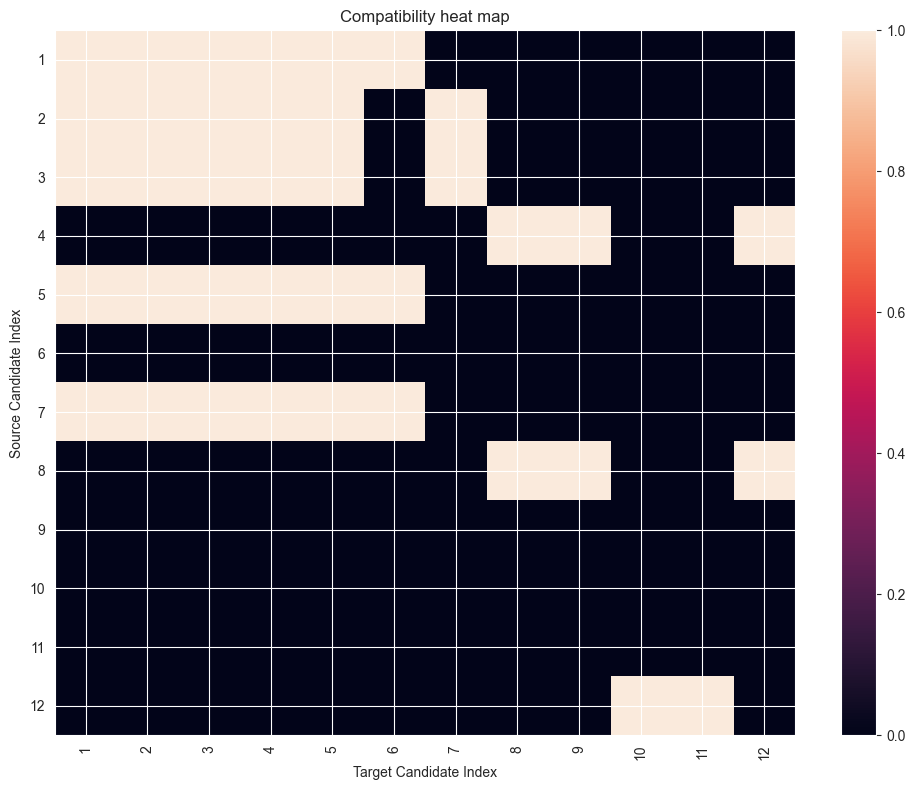

In [73]:
fig = plt.figure(figsize=(10, 8))
plt.imshow(heat_df.values, aspect="auto")
plt.colorbar()
plt.xticks(ticks=np.arange(len(heat_df.columns)), labels=np.arange(1, len(heat_df.columns)+1), rotation=90)
plt.yticks(ticks=np.arange(len(heat_df.index)), labels=np.arange(1, len(heat_df.index)+1))
plt.title("Compatibility heat map")
plt.xlabel("Target Candidate Index")
plt.ylabel("Source Candidate Index")
plt.tight_layout()
plt.show()


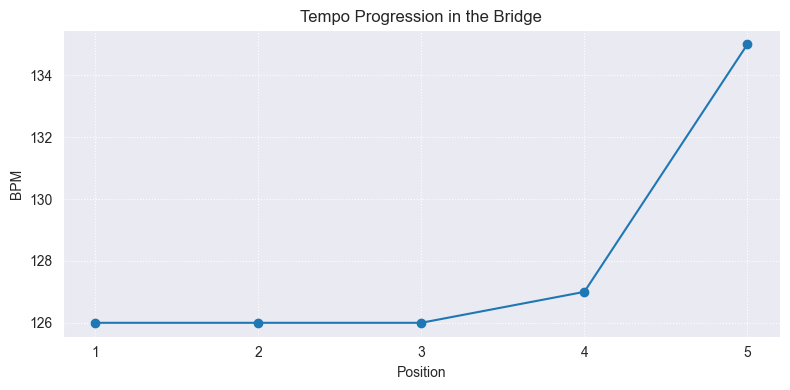

In [74]:
fig = plt.figure(figsize=(8, 4))
vals = pd.to_numeric(bridge_df["tempo"], errors="coerce").astype(float).values
plt.plot(range(1, len(vals)+1), vals, marker="o")
plt.xticks(range(1, len(vals)+1), [str(i) for i in range(1, len(vals)+1)])
plt.title("Tempo Progression in the Bridge")
plt.xlabel("Position")
plt.ylabel("BPM")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()


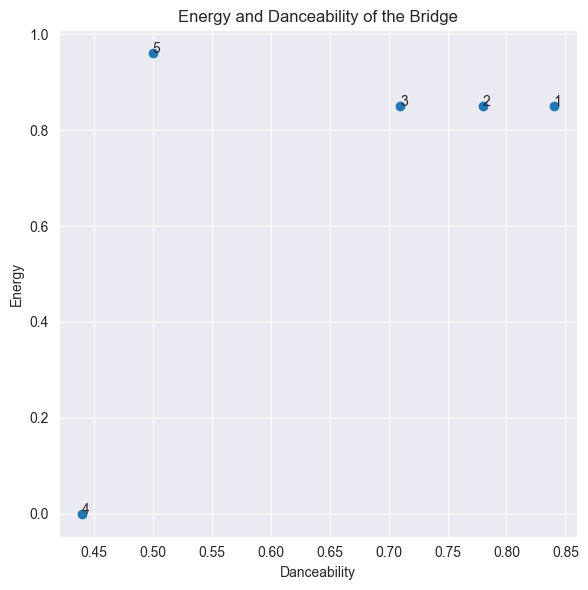

In [75]:
fig = plt.figure(figsize=(6, 6))
x = pd.to_numeric(bridge_df["danceability"], errors="coerce").astype(float).values
y = pd.to_numeric(bridge_df["energy"], errors="coerce").astype(float).values
plt.scatter(x, y)
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.text(xi, yi, str(i+1))
plt.title("Energy and Danceability of the Bridge")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()


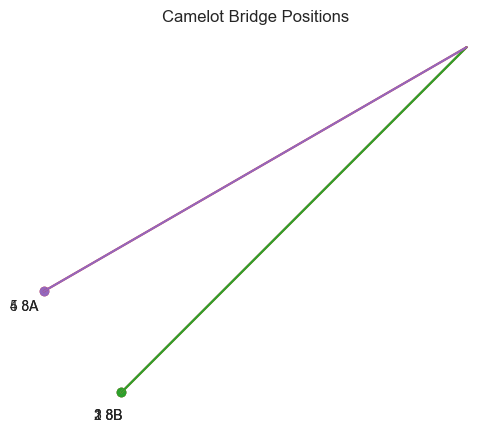

In [76]:
def camelot_to_angle(tag: str) -> float:
    if not isinstance(tag, str) or len(tag) < 2:
        return 0.0
    try:
        n = int(tag[:-1])
        l = 1.0 if tag[-1].upper() == "B" else 0.0
        return (n-1) * (2*math.pi/12.0) + l * (math.pi/12.0)
    except Exception:
        return 0.0

fig = plt.figure(figsize=(6, 6))
ax = plt.gca()
ax.set_aspect("equal")

r = 1.0
for i, row in bridge_df.reset_index().iterrows():
    ang = camelot_to_angle(str(row.get("camelot")))
    x = r * math.cos(ang)
    y = r * math.sin(ang)
    plt.plot([0, x], [0, y])
    plt.scatter([x], [y])
    label = f"{i+1} {row.get('camelot', '')}"
    plt.text(x*1.08, y*1.08, label)
plt.title("Camelot Bridge Positions")
plt.axis("off")
plt.show()
